In [1]:
import pandas as pd

df = pd.read_csv("clean_hr_data.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1472 non-null   float64
 1   Attrition                 1472 non-null   object 
 2   BusinessTravel            1472 non-null   object 
 3   DailyRate                 1472 non-null   int64  
 4   Department                1472 non-null   object 
 5   DistanceFromHome          1472 non-null   int64  
 6   Education                 1472 non-null   int64  
 7   EducationField            1472 non-null   object 
 8   EmployeeCount             1472 non-null   int64  
 9   EmployeeNumber            1472 non-null   int64  
 10  EnvironmentSatisfaction   1472 non-null   int64  
 11  Gender                    1472 non-null   object 
 12  HourlyRate                1472 non-null   int64  
 13  JobInvolvement            1472 non-null   int64  
 14  JobLevel

In [3]:
df['Attrition'].value_counts()

Attrition
No     1234
Yes     238
Name: count, dtype: int64

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.8779661016949153


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[252   2]
 [ 34   7]]


In [10]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
17,MonthlyIncome,0.074139
0,Age,0.060170
2,DailyRate,0.055475
27,TotalWorkingYears,0.051855
18,MonthlyRate,0.050882
21,OverTime,0.050423
11,HourlyRate,0.048503
8,EmployeeNumber,0.044735
4,DistanceFromHome,0.041283
19,NumCompaniesWorked,0.038558


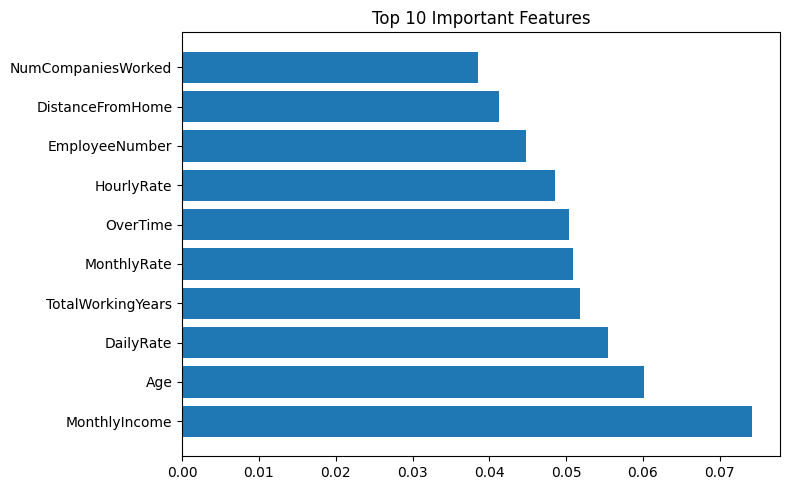

In [11]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()